In [34]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mplsoccer import VerticalPitch
import time
from tqdm import tqdm
import seaborn as sns

from scipy.stats import norm, lognorm

import statsmodels.api as sm
import statsmodels.formula.api as smf


sys.path.append("../")
from xThreat import xThreat

sns.set_theme(style='whitegrid')

In [35]:
# max_max_error = 0.014
# max_max_error = 0.030714285714285715

# Import the data

In [ ]:
# Load both old and new error dataframes
df_errors_old = pd.read_csv('../../3-calculate-values/model-error-distribution/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors_new = pd.read_csv('../../3-calculate-values/model-error-distribution/bootstrap_errors_normal_xthreat_extended.csv').rename(columns={'sample_size': 'N'})

# Append the new errors to the old errors
df_errors = pd.concat([df_errors_old, df_errors_new], ignore_index=True)

# df_errors = pd.read_csv(r'..\3-calculate-values\max-error-quartile-changes\calc-model-error\bootstrap_errors_normal_xthreat_max_error_full.csv').rename(columns={'sample_size': 'N'})
# df_errors = pd.read_csv('../3-calculate-values/calc-model-error/bootstrap_errors_normal_xthreat_max_error_full.csv')

In [37]:
# Add additional columns
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']
df_errors['M/sqrt(N)'] = df_errors['M']*df_errors['1/sqrt(N)']
df_errors['log(M)/sqrt(N)'] = np.log(df_errors['M'])*df_errors['1/sqrt(N)']
df_errors['M^{3/2}log(M)'] = (df_errors['M']**1.5)*np.log(df_errors['M'])
df_errors['M^{3/2}log(M)/sqrt(N)'] = df_errors['M^{3/2}log(M)']*df_errors['1/sqrt(N)']

In [38]:
# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if '2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

In [39]:
df_errors.head()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,weighted_transition_matrix_error_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),M^{3/2}log(M),M^{3/2}log(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,1.0,1.0,0.005083,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,1.0,1.0,0.003691,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,1.0,1.0,0.006166,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,1.0,1.0,0.004812,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,1.0,1.0,0.006745,192,0.0005,0.50472,0.096,0.002629,13987.198625,6.993599


In [40]:
df_errors.describe()

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,weighted_transition_matrix_error_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N),M/sqrt(N),log(M)/sqrt(N),M^{3/2}log(M),M^{3/2}log(M)/sqrt(N)
count,104000.000000,104000.000000,1.040000e+05,104000.000000,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,...,104000.0,1.040000e+05,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,104000.000000,1.040000e+05,104000.000000
mean,28.615385,21.538462,8.675000e+05,499.500000,2.974503e+06,0.002411,0.001614,0.018743,0.002998,0.001362,...,1.0,1.000000e+00,0.097886,847.846154,0.001835,11.341260,1.556148,0.011063,2.640548e+05,484.649761
std,17.617988,13.141983,1.240810e+06,288.676378,1.791256e+06,0.002003,0.001451,0.007044,0.002652,0.000662,...,0.0,2.235204e-16,0.136676,934.112527,0.000873,16.215806,2.037898,0.005878,4.069730e+05,858.737253
min,8.000000,6.000000,1.000000e+05,0.000000,6.880420e+05,0.000060,0.000025,0.003151,0.000073,0.000294,...,1.0,1.000000e+00,0.000422,48.000000,0.000500,0.092909,0.024000,0.001936,1.287382e+03,0.643691
25%,14.000000,11.000000,1.600000e+05,249.750000,1.489292e+06,0.000960,0.000556,0.014339,0.001107,0.000801,...,1.0,1.000000e+00,0.010624,154.000000,0.001164,1.089480,0.221524,0.006314,9.626068e+03,12.625974
50%,24.000000,18.000000,3.050000e+05,499.500000,2.464542e+06,0.001771,0.001091,0.018662,0.002057,0.001288,...,1.0,1.000000e+00,0.043155,432.000000,0.001843,4.202079,0.642976,0.010556,5.448810e+04,80.971587
75%,40.000000,30.000000,7.975000e+05,749.250000,4.256791e+06,0.003241,0.002210,0.022536,0.004038,0.001876,...,1.0,1.000000e+00,0.134260,1200.000000,0.002512,14.028312,1.995301,0.015279,2.947290e+05,473.371116
max,64.000000,48.000000,4.000000e+06,999.000000,8.705041e+06,0.011238,0.007951,0.067543,0.014307,0.003546,...,1.0,1.000000e+00,1.159943,3072.000000,0.003162,78.008388,9.714517,0.025393,1.367263e+06,4323.663738


In [41]:
print("Possible values of n_x", df_errors['n_x'].unique().tolist())
print("Possible values of n_y", df_errors['n_y'].unique().tolist())
print("Possible values of N", df_errors['N'].unique().tolist())
print("Possible values of M", df_errors['M'].unique().tolist())

Possible values of n_x [16, 32, 40, 48, 56, 64, 8, 10, 12, 14, 20, 24, 28]
Possible values of n_y [12, 24, 30, 36, 42, 48, 6, 8, 9, 11, 15, 18, 21]
Possible values of N [4000000, 1300000, 630000, 370000, 240000, 170000, 130000, 100000]
Possible values of M [192, 768, 1200, 1728, 2352, 3072, 48, 80, 108, 154, 300, 432, 588]


# General result inspection

[(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0)), (np.float64(0.275191), np.float64(0.194905), np.float64(0.496005), np.float64(1.0)), (np.float64(0.212395), np.float64(0.359683), np.float64(0.55171), np.float64(1.0)), (np.float64(0.151918), np.float64(0.500685), np.float64(0.557587), np.float64(1.0)), (np.float64(0.12478), np.float64(0.640461), np.float64(0.527068), np.float64(1.0)), (np.float64(0.311925), np.float64(0.767822), np.float64(0.415586), np.float64(1.0)), (np.float64(0.616293), np.float64(0.852709), np.float64(0.230052), np.float64(1.0)), (np.float64(0.993248), np.float64(0.906157), np.float64(0.143936), np.float64(1.0))]


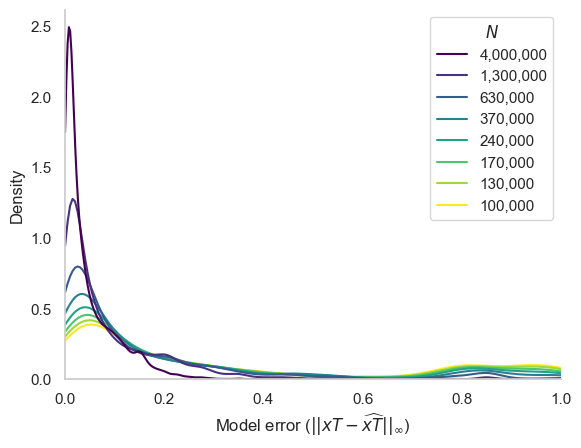

In [42]:
cmap = 'viridis'

ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue='1/sqrt(N)', palette=cmap, clip=(0, 1))

# Get the unique hue values ('1/sqrt(N)')
hue_levels = np.unique(df_errors['1/sqrt(N)'])
rounded_hue_levels = [f"{int(1/level**2):,}" for level in hue_levels]

# Create a color palette based on the hue values
cmap = matplotlib.colormaps[cmap]
palette = [cmap( (hue_level-hue_levels.min())/(hue_levels.max()-hue_levels.min()) ) for hue_level in hue_levels]
print(cmap)
# Create custom legend handles: we need to map each color to the corresponding hue value
handles = [matplotlib.lines.Line2D([0], [0], color=palette[i]) for i in range(len(hue_levels))]

# Set the legend with the correct rounded labels
ax.legend(handles, rounded_hue_levels, title=r"$N$")
print(palette)
# Set the x-axis label
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")

ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
ax.set_xlim(0, max(1.0, df_errors['xT_error_inf_norm'].max()))

plt.show()

[(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0)), (np.float64(0.279574), np.float64(0.170599), np.float64(0.479997), np.float64(1.0)), (np.float64(0.257322), np.float64(0.25613), np.float64(0.526563), np.float64(1.0)), (np.float64(0.21621), np.float64(0.351535), np.float64(0.550627), np.float64(1.0)), (np.float64(0.190631), np.float64(0.407061), np.float64(0.556089), np.float64(1.0)), (np.float64(0.149039), np.float64(0.508051), np.float64(0.55725), np.float64(1.0)), (np.float64(0.121148), np.float64(0.592739), np.float64(0.544641), np.float64(1.0)), (np.float64(0.137339), np.float64(0.662252), np.float64(0.515571), np.float64(1.0)), (np.float64(0.20803), np.float64(0.718701), np.float64(0.472873), np.float64(1.0)), (np.float64(0.421908), np.float64(0.805774), np.float64(0.35191), np.float64(1.0)), (np.float64(0.636902), np.float64(0.856542), np.float64(0.21662), np.float64(1.0)), (np.float64(0.83527), np.float64(0.886029), np.float64(0.102646), np.f

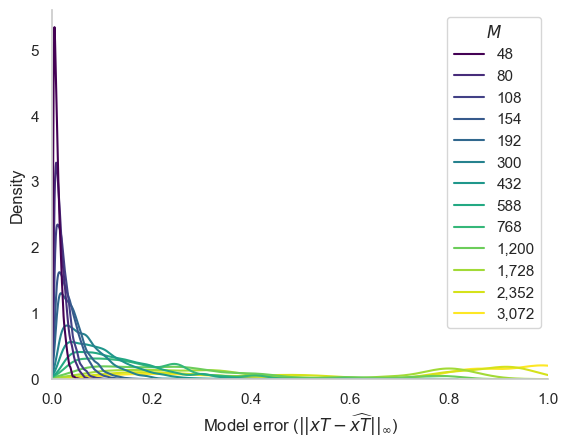

In [43]:
cmap = 'viridis'


ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue=np.log(df_errors['M']), palette=cmap)

# Get the unique hue values ('M')
hue_levels = np.unique(np.log(df_errors['M']))
labels = [f"{int(level):,}" for level in np.unique(df_errors['M'])]

# Create a color palette based on the hue values
cmap = matplotlib.colormaps[cmap]
palette = [cmap( (hue_level-hue_levels.min())/(hue_levels.max()-hue_levels.min()) ) for hue_level in hue_levels]
print(cmap)
# Create custom legend handles: we need to map each color to the corresponding hue value
handles = [matplotlib.lines.Line2D([0], [0], color=palette[i]) for i in range(len(hue_levels))]

# Set the legend with the correct rounded labels
ax.legend(handles, labels, title=r"$M$")
print(palette)
# Set the x-axis label
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")

ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
ax.set_xlim(0, max(1.0, df_errors['xT_error_inf_norm'].max()))

plt.show()

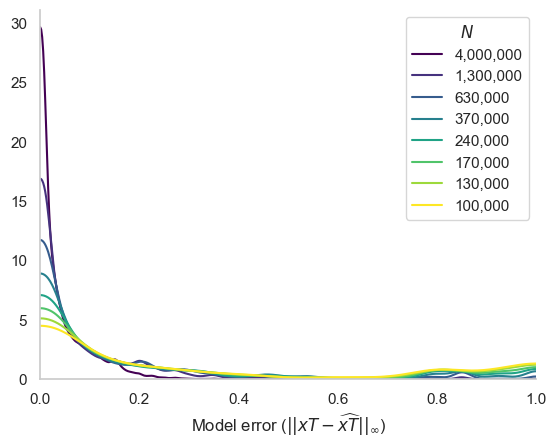

In [44]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib
import matplotlib.lines
import matplotlib.pyplot as plt

def bounded_bandwidth(data):
    """Scott's rule corrected for bounded support near 0."""
    n = len(data)
    # Use IQR-based spread instead of std, more robust near boundaries
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    std = min(data.std(), iqr / 1.34)
    return 0.9 * std * n**(-1/5)  # classic Silverman, but on robust spread

def reflected_kde(data, x_grid, bw=None):
    reflected = np.concatenate([data, -data, 2 - data])
    bw = bw or bounded_bandwidth(data)
    kde = gaussian_kde(reflected, bw_method=bw / reflected.std())
    return kde(x_grid) * 3

x_grid = np.linspace(0, 1, 500)
cmap_name = 'viridis'
cmap = matplotlib.colormaps[cmap_name]
hue_levels = np.sort(np.unique(df_errors['1/sqrt(N)']))

fig, ax = plt.subplots()

for i, level in enumerate(hue_levels):
    data = df_errors.loc[
        df_errors['1/sqrt(N)'] == level, 'xT_error_inf_norm'
    ].dropna().values
    color = cmap(
        (level - hue_levels.min()) / (hue_levels.max() - hue_levels.min())
    )
    density = reflected_kde(data, x_grid)
    ax.plot(x_grid, density, color=color)

# Legend
rounded = [f"{int(1/l**2):,}" for l in hue_levels]
handles = [
    matplotlib.lines.Line2D([0], [0], color=cmap(
        (l - hue_levels.min()) / (hue_levels.max() - hue_levels.min())
    )) for l in hue_levels
]
ax.legend(handles, rounded, title=r"$N$")
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")
ax.set_xlim(0, max(1.0, df_errors['xT_error_inf_norm'].max()))
ax.set_ylim(0, None)
ax.spines[['top', 'right']].set_visible(False)
# ax.spines['bottom'].set_position(('data', 0))
ax.grid(False)
plt.show()

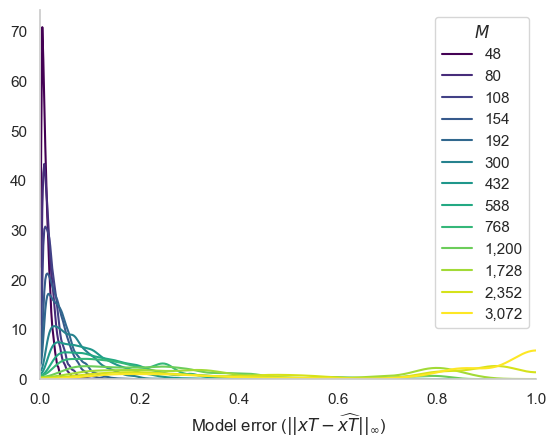

In [45]:
x_grid = np.linspace(0, 1, 500)
cmap_name = 'viridis'
cmap = matplotlib.colormaps[cmap_name]

# Use log(M) just like in the first plot
hue_levels = np.sort(np.unique(df_errors['M']))
log_levels = np.log(hue_levels)

fig, ax = plt.subplots()

for i, level in enumerate(hue_levels):
    data = df_errors.loc[
        df_errors['M'] == level, 'xT_error_inf_norm'
    ].dropna().values
    
    color = cmap(
        (np.log(level) - log_levels.min()) / (log_levels.max() - log_levels.min())
    )
    
    density = reflected_kde(data, x_grid)
    ax.plot(x_grid, density, color=color)

# Legend (same mapping!)
rounded = [f"{int(l):,}" for l in hue_levels]
handles = [
    matplotlib.lines.Line2D(
        [0], [0],
        color=cmap(
            (np.log(l) - log_levels.min()) / (log_levels.max() - log_levels.min())
        )
    )
    for l in hue_levels
]

ax.legend(handles, rounded, title=r"$M$")
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")
ax.set_xlim(0, max(1.0, df_errors['xT_error_inf_norm'].max()))
ax.set_ylim(0, None)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)

plt.show()

In [46]:
df_errors.columns

Index(['n_x', 'n_y', 'N', 'i_bootstrap', 'random_state', 'xT_error_1_norm',
       'g_error_1_norm', 'xG_error_1_norm', 'prob_shot_error_1_norm',
       'transition_matrix_error_1_norm', 'transition_matrix_true_1_norm',
       'transition_matrix_resampled_1_norm',
       'weighted_transition_matrix_error_1_norm', 'xT_error_inf_norm',
       'g_error_inf_norm', 'xG_error_inf_norm', 'prob_shot_error_inf_norm',
       'transition_matrix_error_inf_norm', 'transition_matrix_true_inf_norm',
       'transition_matrix_resampled_inf_norm',
       'weighted_transition_matrix_error_inf_norm', 'M', '1/sqrt(N)',
       'Mlog(M)/sqrt(N)', 'M/sqrt(N)', 'log(M)/sqrt(N)', 'M^{3/2}log(M)',
       'M^{3/2}log(M)/sqrt(N)'],
      dtype='object')

In [47]:
np.sum(df_errors['M^{3/2}log(M)/sqrt(N)'] > 445)

np.int64(28000)

In [48]:
df_errors.shape

(104000, 28)

[(np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0)), (np.float64(0.279574), np.float64(0.170599), np.float64(0.479997), np.float64(1.0)), (np.float64(0.257322), np.float64(0.25613), np.float64(0.526563), np.float64(1.0)), (np.float64(0.21621), np.float64(0.351535), np.float64(0.550627), np.float64(1.0)), (np.float64(0.190631), np.float64(0.407061), np.float64(0.556089), np.float64(1.0)), (np.float64(0.149039), np.float64(0.508051), np.float64(0.55725), np.float64(1.0)), (np.float64(0.121148), np.float64(0.592739), np.float64(0.544641), np.float64(1.0)), (np.float64(0.137339), np.float64(0.662252), np.float64(0.515571), np.float64(1.0)), (np.float64(0.20803), np.float64(0.718701), np.float64(0.472873), np.float64(1.0)), (np.float64(0.421908), np.float64(0.805774), np.float64(0.35191), np.float64(1.0)), (np.float64(0.636902), np.float64(0.856542), np.float64(0.21662), np.float64(1.0)), (np.float64(0.83527), np.float64(0.886029), np.float64(0.102646), np.f

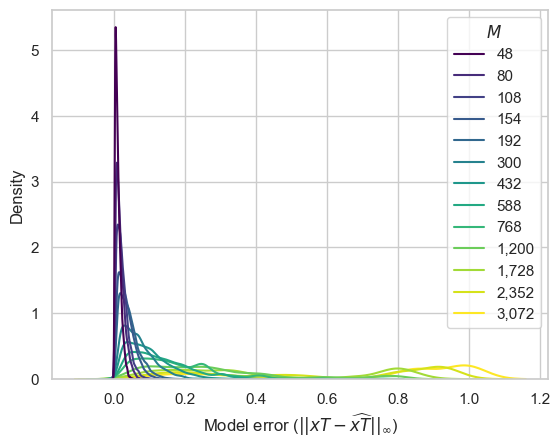

In [49]:
cmap = 'viridis'


ax = sns.kdeplot(data=df_errors, x='xT_error_inf_norm', hue=np.log(df_errors['M']), palette=cmap)

# Get the unique hue values ('M')
hue_levels = np.unique(np.log(df_errors['M']))
labels = [f"{int(level):,}" for level in np.unique(df_errors['M'])]

# Create a color palette based on the hue values
cmap = matplotlib.colormaps[cmap]
palette = [cmap( (hue_level-hue_levels.min())/(hue_levels.max()-hue_levels.min()) ) for hue_level in hue_levels]
print(cmap)
# Create custom legend handles: we need to map each color to the corresponding hue value
handles = [matplotlib.lines.Line2D([0], [0], color=palette[i]) for i in range(len(hue_levels))]

# Set the legend with the correct rounded labels
ax.legend(handles, labels, title=r"$M$")
print(palette)
# Set the x-axis label
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")

plt.show()

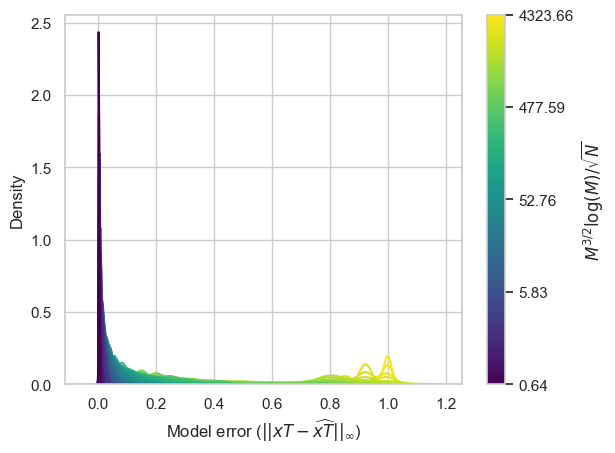

In [50]:
fig, ax = plt.subplots()
norm = plt.Normalize(np.log(df_errors['M^{3/2}log(M)/sqrt(N)'].min()), np.log(df_errors['M^{3/2}log(M)/sqrt(N)'].max()))
sm_ = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm_.set_array([])

sns.kdeplot(
    data=df_errors, 
    x='xT_error_inf_norm', 
    hue=np.log(df_errors['M^{3/2}log(M)/sqrt(N)']), 
    palette='viridis',
    hue_norm=norm,
    ax=ax
)

# Remove the legend
ax.get_legend().remove()
ax.set_xlabel(r"Model error ($||xT-\widehat{xT}||_\infty$)")

# Add a color bar with the correct ticks of 'M^{3/2}log(M)/sqrt(N)'
min_val = np.min(np.log(np.unique(df_errors['M^{3/2}log(M)/sqrt(N)'])))
max_val = np.max(np.log(np.unique(df_errors['M^{3/2}log(M)/sqrt(N)'])))
ticks_positions = np.linspace(min_val, max_val, num=5)
ticks_values = np.exp(ticks_positions)
# ticks_position = np.log(np.unique(df_errors['M^{3/2}log(M)/sqrt(N)']))
# ticks_values = np.unique(df_errors['M^{3/2}log(M)/sqrt(N)'])

# Add a color bar with the correct ticks at the correct places
cbar = plt.colorbar(sm_, ax=ax, ticks=ticks_positions)
cbar.set_ticklabels([f"{val:.2f}" for val in ticks_values])
cbar.set_label(r"$M^{3/2}\log(M)/\sqrt{N}$")

plt.show()

# OLS Modeling

## Defining the cut-off point

4323.663738071074
[   0.   540.5 1081.  1621.5 2162.  2702.5 3243.  3783.5 4324. ]


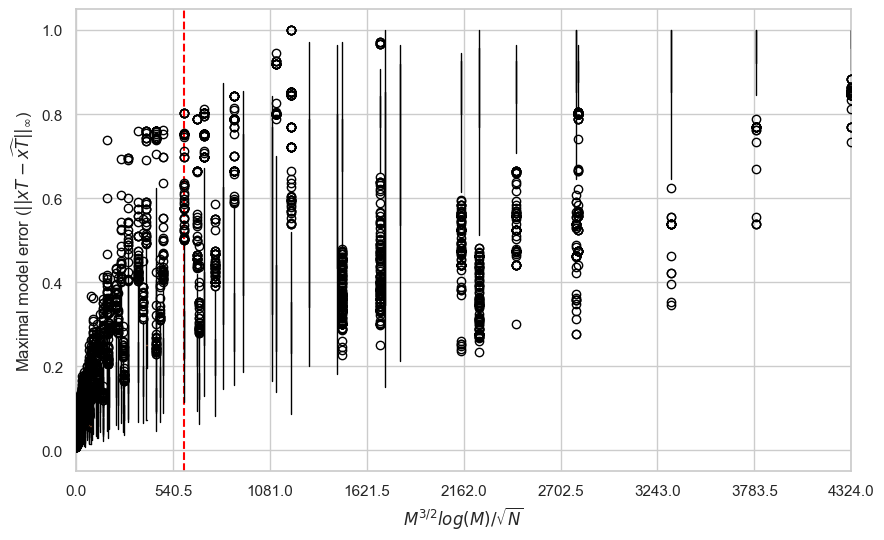

In [51]:
plt.figure(figsize=(10, 6))

vals = df_errors['M^{3/2}log(M)/sqrt(N)'].unique().tolist()
data_listed = [
    df_errors[df_errors['M^{3/2}log(M)/sqrt(N)'] == val]['xT_error_inf_norm'].tolist()
    for val in vals
]

for idx, (val, data_points) in enumerate(zip(vals, data_listed)):
    plt.boxplot(
        data_points,
        positions=[val],
        # widths=0.5,
        # patch_artist=True,
        # medianprops=dict(color='black', linewidth=1),
        # # boxprops=dict(facecolor='lightblue', color='black', linewidth=1),
        # boxprops=dict(facecolor=color, color='black', linewidth=1),
        # # boxprops=dict(facecolor='#4C72B0', color='black'),
        # capprops=dict(color='black'),
        # whiskerprops=dict(color='black'),
        # flierprops=dict(markerfacecolor='white', marker='o', markersize=4, alpha=0.5),
        zorder=idx,
    )
plt.axvline(x=602.35, color='red', linestyle='--', label='Threshold at 602.35')
plt.grid(True)
plt.xlim(0, np.ceil(max(vals)))
n_ticks = 9
ticks = np.linspace(0.0, np.ceil(max(vals)), n_ticks)
print(max(vals))
print(ticks)
plt.xticks(ticks, labels=ticks)
plt.xlabel(r'$M^{3/2}log(M)/\sqrt{N}$')
plt.ylabel(r'Maximal model error ($||xT-\widehat{xT}||_{\infty}$)')
plt.show()

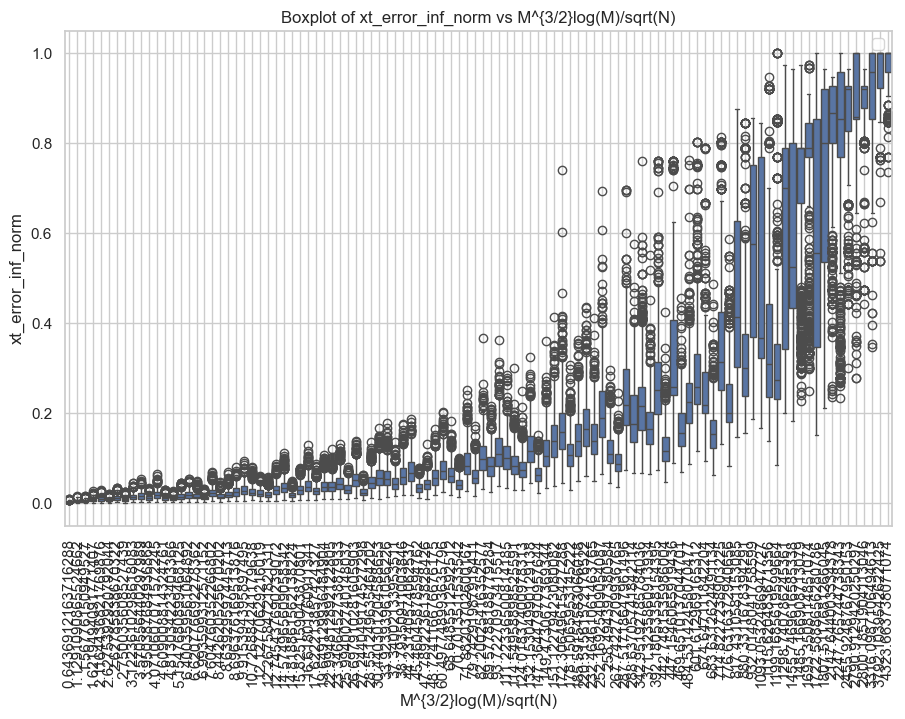

In [52]:
# Plot a boxplot of the errors for each value of Mlog(M)/sqrt(N)
plt.figure(figsize=(10, 6))
sns.boxplot(x='M^{3/2}log(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors)
# plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('M^{3/2}log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Boxplot of xt_error_inf_norm vs M^{3/2}log(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xticks(rotation=90)

plt.show()

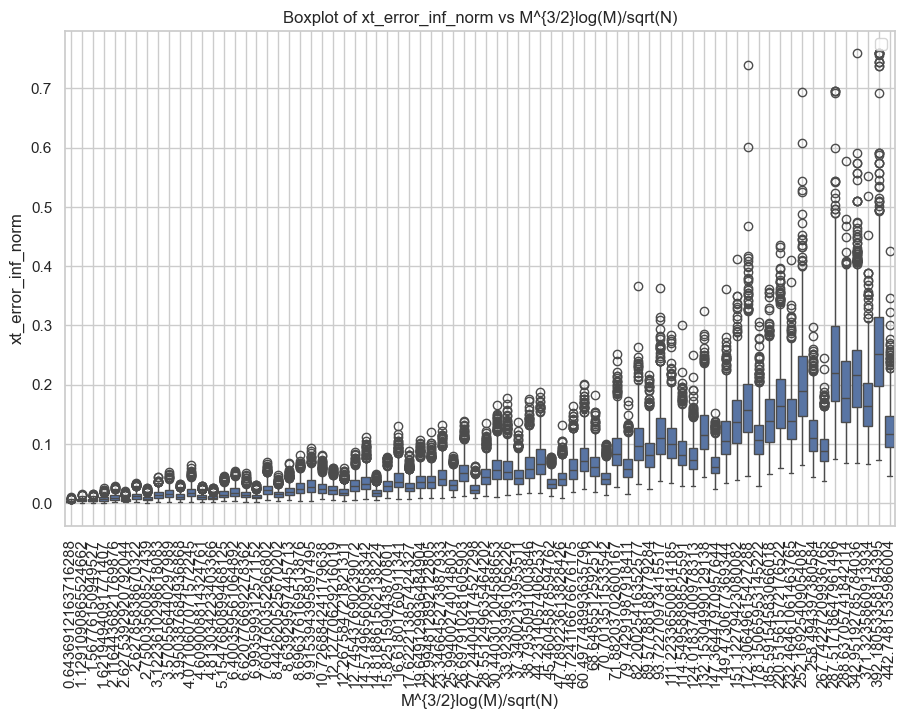

In [53]:
df_errors_ols = df_errors[df_errors['M^{3/2}log(M)/sqrt(N)'] < 445].copy()
# df_errors_ols = df_errors[df_errors['Mlog(M)/sqrt(N)'] < 15].copy()


# Plot a boxplot of the errors for each value of Mlog(M)/sqrt(N)
plt.figure(figsize=(10, 6))
sns.boxplot(x='M^{3/2}log(M)/sqrt(N)', y='xT_error_inf_norm', data=df_errors_ols)
# plt.axhline(y=max_max_error, color='red', linestyle='--', label='max_max_error')
plt.xlabel('M^{3/2}log(M)/sqrt(N)')
plt.ylabel('xt_error_inf_norm')
plt.title('Boxplot of xt_error_inf_norm vs M^{3/2}log(M)/sqrt(N)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.xticks(rotation=90)

plt.show()



# Applying OLS to the filtered dataset

In [54]:
# df_errors_ols = df_errors[df_errors['Mlog(M)/sqrt(N)'] < 15].copy()
df_errors_ols = df_errors[df_errors['M^{3/2}log(M)/sqrt(N)'] < 445].copy()
df_errors_ols['sqrt(M)log(M)/sqrt(N)'] = df_errors_ols['log(M)/sqrt(N)'] * np.sqrt(df_errors_ols['M'])

                            OLS Regression Results                            
Dep. Variable:      xT_error_inf_norm   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                 2.416e+05
Date:                 vr, 17 apr 2026   Prob (F-statistic):               0.00
Time:                        23:21:55   Log-Likelihood:                -42284.
No. Observations:               76000   AIC:                         8.457e+04
Df Residuals:                   75997   BIC:                         8.460e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.0916      0.017   -121.

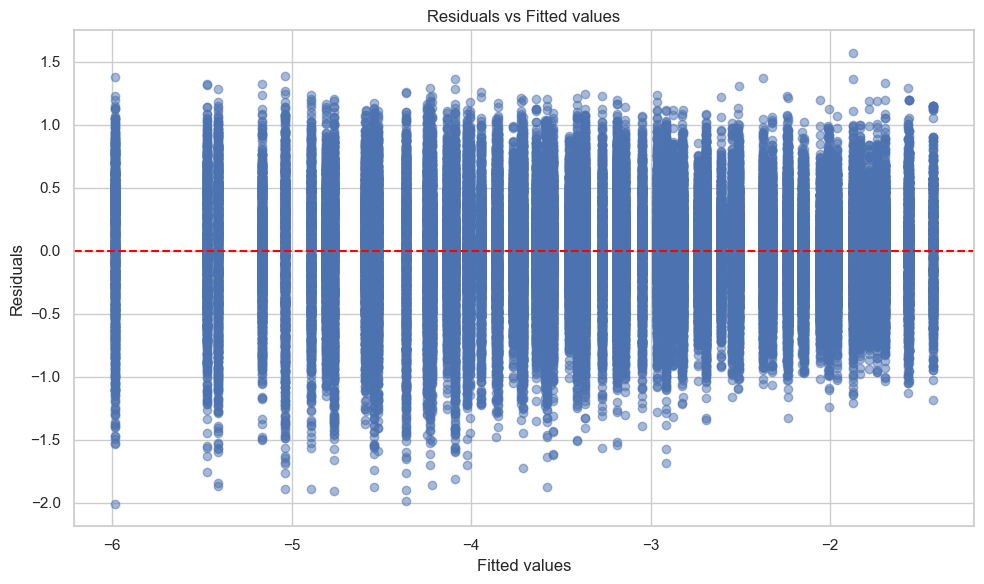

In [55]:
# Do OLS regression on log transformations

X = sm.add_constant(pd.DataFrame({
    'log(M)': np.log(df_errors_ols['M']),
    'log(1/sqrt(N))': -np.log(np.sqrt(df_errors_ols['N']))
    }))
Y = np.log(df_errors_ols['xT_error_inf_norm'])
# Fit the model
model = sm.OLS(Y,X)
results = model.fit()
print(results.summary())

# Plot the residuals and values
plt.figure(figsize=(10, 6))
plt.scatter(results.fittedvalues, results.resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted values')
plt.grid(True)
plt.tight_layout()
plt.show()





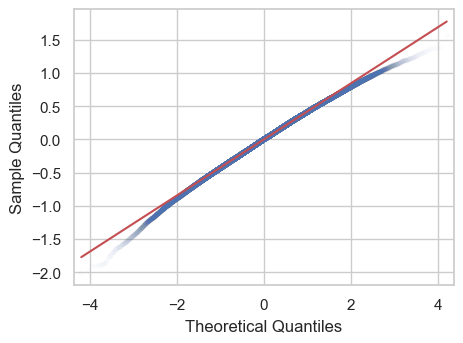

In [56]:
# Plot the QQ plot of the residuals
# fig, ax = plt.subplots(figsize=(6.4, 4.8))
fig, ax = plt.subplots(figsize=(4.8, 3.6))
# fig, ax = plt.subplots(figsize=(3.2, 2.4))
sm.qqplot(results.resid, line='s', ax = ax, alpha=0.01, markersize=3)
# plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

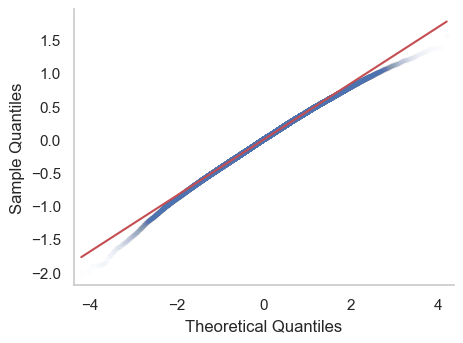

In [57]:
# Plot the QQ plot of the residuals
# fig, ax = plt.subplots(figsize=(6.4, 4.8))
fig, ax = plt.subplots(figsize=(4.8, 3.6))
# fig, ax = plt.subplots(figsize=(3.2, 2.4))
sm.qqplot(results.resid, line='s', ax = ax, alpha=0.01, markersize=3)
# plt.title('QQ plot of residuals')
ax.grid(False)
plt.tight_layout()
ax.spines[['top', 'right']].set_visible(False)
plt.show()

In [58]:
c = results.params['const']
power = results.params['log(M)']
std_residuals = np.sqrt(results.mse_resid)
beta = results.params['log(1/sqrt(N))']
print(f"c={c}")
print(f"power={power}")
print(f"std_residuals={std_residuals}")
print(f"Variance residuals={results.mse_resid}")
print(f"beta={beta}")

c=-2.0915784326697198
power=1.0099919011379082
std_residuals=0.4220842476334173
Variance residuals=0.1781551121002679
beta=1.0266672599410456


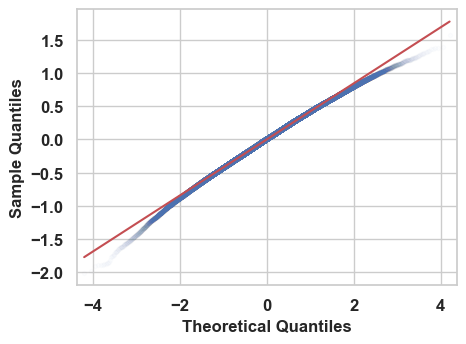

In [59]:
# Plot the QQ plot of the residuals
# fig, ax = plt.subplots(figsize=(6.4, 4.8))
fig, ax = plt.subplots(figsize=(4.8, 3.6))
# fig, ax = plt.subplots(figsize=(3.2, 2.4))
sm.qqplot(results.resid, line='s', ax = ax, alpha=0.01, markersize=3)
# plt.title('QQ plot of residuals')
plt.grid(True)
plt.tight_layout()

fig.axes[0].set_xlabel('Theoretical Quantiles', weight='bold')
fig.axes[0].set_ylabel('Sample Quantiles', weight='bold')
plt.xticks(fontweight='bold', fontsize=12)
plt.yticks(fontweight='bold', fontsize=12)

plt.show()

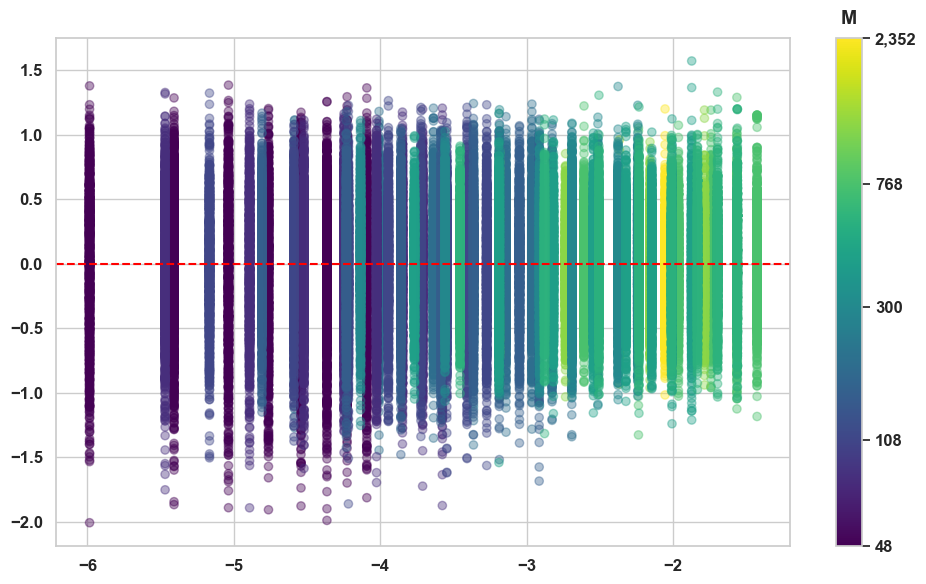

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Plot
plt.figure(figsize=(10,6))
sc = plt.scatter(results.fittedvalues, results.resid, c=np.log(df_errors_ols['M']), cmap='viridis', alpha=0.4)
plt.axhline(0, color='red', linestyle='--')

cbar = plt.colorbar(sc)
cbar.solids.set_alpha(1)
ticks = np.log(np.quantile(df_errors_ols['M'], [0.0, 0.25, 0.6, 0.92, 1.0]))
cbar.set_ticks(ticks)

# — Apply exponential transform to tick labels —
def exp_formatter(x, pos):
    # as an integer
    return f"{int(np.round(np.exp(x))):,}"

cbar.formatter = FuncFormatter(exp_formatter)
cbar.update_ticks()

cbar.ax.set_title("M", weight='bold', pad=10, fontsize=14)
fig.axes[0].set_xlabel('Theoretical Quantiles', weight='bold')
fig.axes[0].set_ylabel('Sample Quantiles', weight='bold')
plt.xticks(fontweight='bold', fontsize=12)
plt.yticks(fontweight='bold', fontsize=12)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)
    
plt.tight_layout()
plt.show()


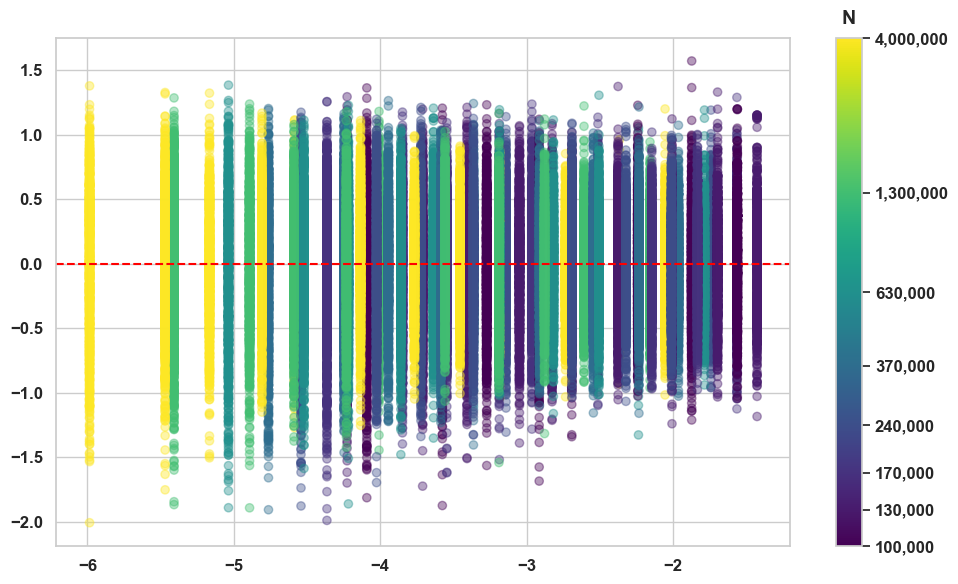

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Plot
plt.figure(figsize=(10,6))
sc = plt.scatter(results.fittedvalues, results.resid, c=np.log(df_errors_ols['N']), cmap='viridis', alpha=0.4)
plt.axhline(0, color='red', linestyle='--')

cbar = plt.colorbar(sc)
cbar.solids.set_alpha(1)
ticks = np.log(np.quantile(df_errors_ols['N'], [0.0, 0.3, 0.5, 0.6, 0.75, 1.0]))
ticks = np.log(df_errors_ols['N'].unique().tolist())
cbar.set_ticks(ticks)

# — Apply exponential transform to tick labels —
def exp_formatter(x, pos):
    # as an integer
    return f"{int(np.round(np.exp(x))):,}"

cbar.formatter = FuncFormatter(exp_formatter)
cbar.update_ticks()

cbar.ax.set_title("N", weight='bold', pad=10, fontsize=14)
fig.axes[0].set_xlabel('Theoretical Quantiles', weight='bold')
fig.axes[0].set_ylabel('Sample Quantiles', weight='bold')
plt.xticks(fontweight='bold', fontsize=12)
plt.yticks(fontweight='bold', fontsize=12)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

plt.tight_layout()
plt.show()


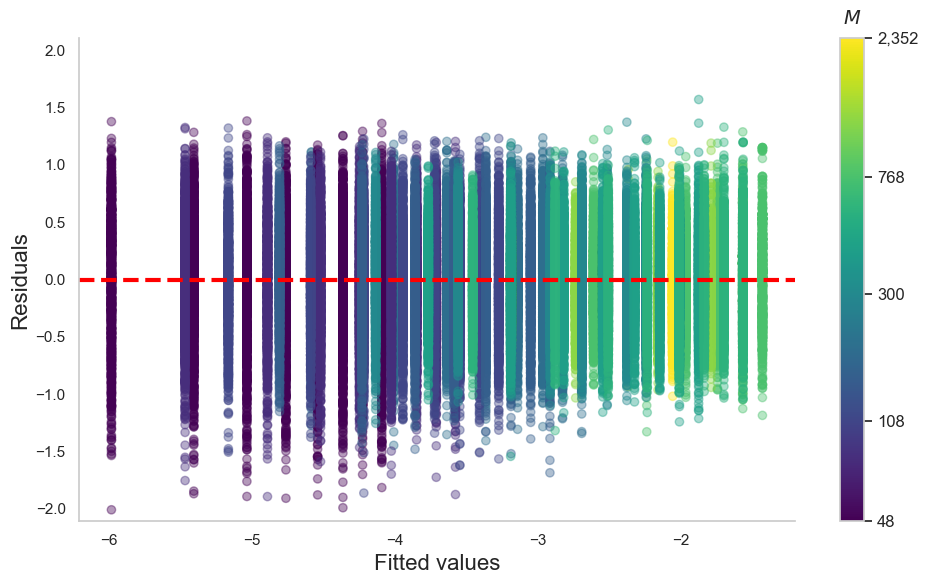

In [62]:
# Plot
fig, axes = plt.subplots(1, 1, figsize=(10,6))
sc = axes.scatter(results.fittedvalues, results.resid, c=np.log(df_errors_ols['M']), cmap='viridis', alpha=0.4)
axes.axhline(0, color='red', linestyle='--', linewidth=3)

cbar = plt.colorbar(sc)
cbar.solids.set_alpha(1)
ticks = np.log(np.quantile(df_errors_ols['M'], [0.0, 0.25, 0.6, 0.92, 1.0]))
cbar.set_ticks(ticks)

# — Apply exponential transform to tick labels —
def exp_formatter(x, pos):
    # as an integer
    return f"{int(np.round(np.exp(x))):,}"

cbar.formatter = FuncFormatter(exp_formatter)
cbar.update_ticks()

cbar.ax.set_title("$M$", pad=10, fontsize=14)
# plt.xticks(fontweight='bold', fontsize=12)
# plt.yticks(fontweight='bold', fontsize=12)
for label in cbar.ax.get_yticklabels():
    # label.set_fontweight('bold')
    label.set_fontsize(12)

plt.grid(False)
axes.spines[['top', 'right']].set_visible(False)
axes.set_ylim(-np.max(np.abs(results.resid))-0.1, np.max(np.abs(results.resid))+0.1)
axes.set_xlabel('Fitted values', fontsize=16)
axes.set_ylabel('Residuals', fontsize=16)
plt.tight_layout()
plt.show()


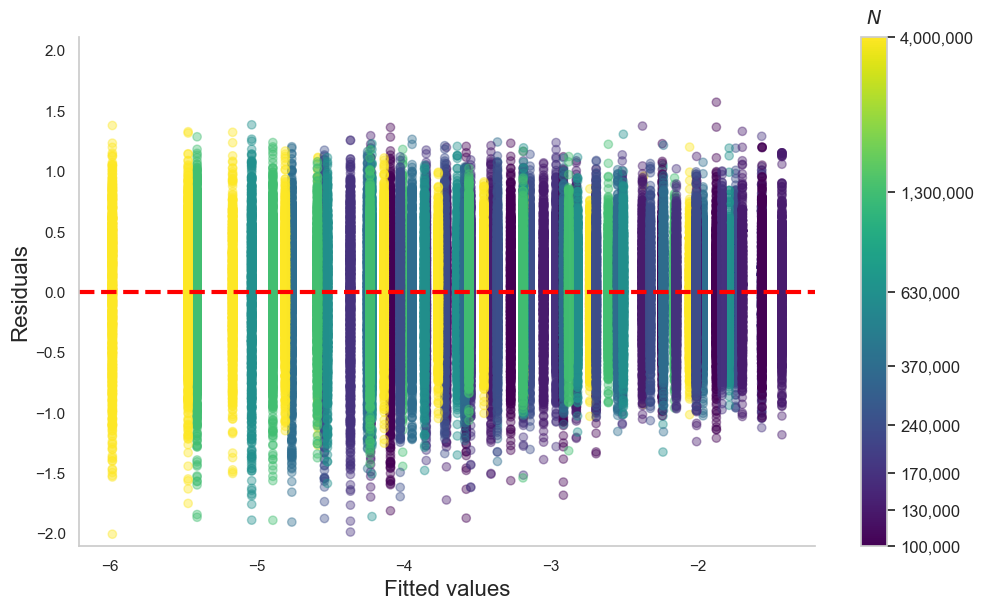

In [63]:
# Plot
fig, axes = plt.subplots(1, 1, figsize=(10,6))
sc = axes.scatter(results.fittedvalues, results.resid, c=np.log(df_errors_ols['N']), cmap='viridis', alpha=0.4)
axes.axhline(0, color='red', linestyle='--', linewidth=3)

cbar = plt.colorbar(sc)
cbar.solids.set_alpha(1)
ticks = np.log(np.quantile(df_errors_ols['N'], [0.0, 0.3, 0.5, 0.6, 0.75, 1.0]))
ticks = np.log(df_errors_ols['N'].unique().tolist())
cbar.set_ticks(ticks)


# — Apply exponential transform to tick labels —
def exp_formatter(x, pos):
    # as an integer
    return f"{int(np.round(np.exp(x))):,}"

cbar.formatter = FuncFormatter(exp_formatter)
cbar.update_ticks()

cbar.ax.set_title("$N$", pad=10, fontsize=14)
# plt.xticks(fontweight='bold', fontsize=12)
# plt.yticks(fontweight='bold', fontsize=12)
for label in cbar.ax.get_yticklabels():
    # label.set_fontweight('bold')
    label.set_fontsize(12)

plt.grid(False)
axes.spines[['top', 'right']].set_visible(False)
axes.set_ylim(-np.max(np.abs(results.resid))-0.1, np.max(np.abs(results.resid))+0.1)
plt.tight_layout()
axes.set_xlabel('Fitted values', fontsize=16)
axes.set_ylabel('Residuals', fontsize=16)
plt.show()


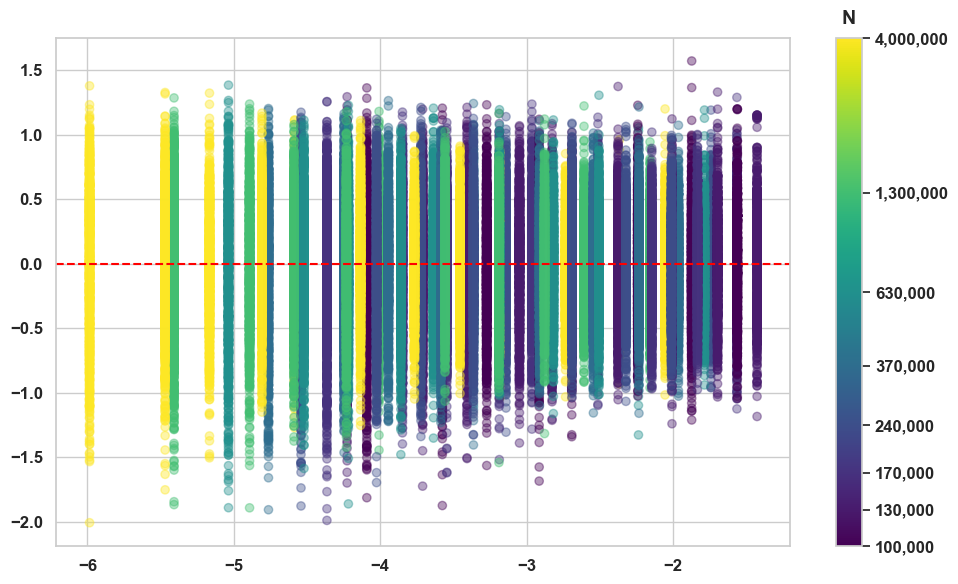

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Plot
plt.figure(figsize=(10,6))
sc = plt.scatter(results.fittedvalues, results.resid, c=np.log(df_errors_ols['N']), cmap='viridis', alpha=0.4)
plt.axhline(0, color='red', linestyle='--')

cbar = plt.colorbar(sc)
cbar.solids.set_alpha(1)
ticks = np.log(np.quantile(df_errors_ols['N'], [0.0, 0.3, 0.5, 0.6, 0.75, 1.0]))
ticks = np.log(df_errors_ols['N'].unique().tolist())
cbar.set_ticks(ticks)

# — Apply exponential transform to tick labels —
def exp_formatter(x, pos):
    # as an integer
    return f"{int(np.round(np.exp(x))):,}"

cbar.formatter = FuncFormatter(exp_formatter)
cbar.update_ticks()

cbar.ax.set_title("N", weight='bold', pad=10, fontsize=14)
fig.axes[0].set_xlabel('Theoretical Quantiles', weight='bold')
fig.axes[0].set_ylabel('Sample Quantiles', weight='bold')
plt.xticks(fontweight='bold', fontsize=12)
plt.yticks(fontweight='bold', fontsize=12)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

plt.tight_layout()
plt.show()


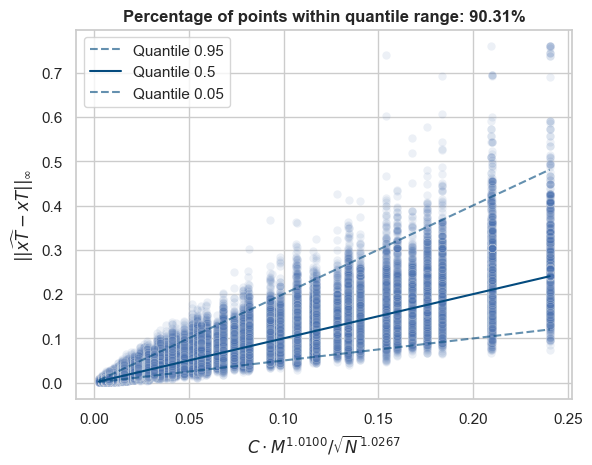

In [65]:
fig, ax = plt.subplots(figsize=(6.4, 4.8))

xs = np.exp(c)*df_errors_ols['M']**power * df_errors_ols['1/sqrt(N)']**beta

sns.scatterplot(
    x=xs,
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
    alpha=0.1,
)

# Add quantiles
quantiles = [0.05, 0.5, 0.95]
linestyles = ['--', '-', '--']
colors = ['blue', 'darkblue', 'blue']
colors = ["#044b7e9d", "#044b7e", '#044b7e9d']


xs_plot = np.linspace(xs.min(), xs.max(), 1000)
for i, q in enumerate(quantiles[::-1]):
    quantile = lognorm.ppf(q, s=std_residuals, scale=xs_plot)
    plt.plot(xs_plot, quantile, label=f'Quantile {q}', linestyle=linestyles[i], color=colors[i])

ax.set_xlabel(r'$C\cdot M^{%.4f} / \sqrt{N}^{%.4f}$' % (power, beta), weight='bold')
ax.set_ylabel(r'$||\widehat{xT} - xT||_{\infty}$', weight='bold')

# Calculate the number of points within the quantile range
within_quantile = df_errors_ols[
    (df_errors_ols['xT_error_inf_norm'] >= lognorm.ppf(0.05, s=std_residuals, scale=xs)) &
    (df_errors_ols['xT_error_inf_norm'] <= lognorm.ppf(0.95, s=std_residuals, scale=xs))
]

within_quantile_count = len(within_quantile)
plt.title(f'Percentage of points within quantile range: {within_quantile_count/len(xs)*100:.2f}%', weight='bold')
# Make it an annotation
# plt.annotate(
#     f'Percentage of points within quantile range: {within_quantile_count/len(xs)*100:.2f}%',
#     xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, ha='left', va='top',
#     bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white')
# )

plt.legend()

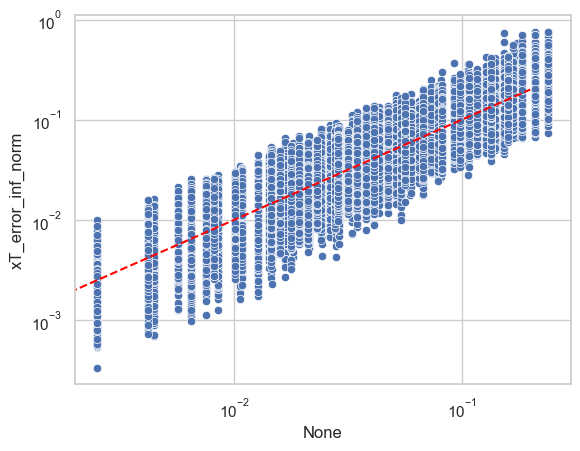

In [66]:
fig, ax =  plt.subplots(figsize=(6.4, 4.8))
ax.set(xscale='log', yscale='log')
sns.scatterplot(
    x=np.exp(results.fittedvalues),
    y=df_errors_ols['xT_error_inf_norm'],
    ax=ax,
)
# Add line y=x
plt.plot([0, 0.2], [0, 0.2], color='red', linestyle='--', label='y=x')